# P2 · 02 — Multi-step forecasting: recursive vs direct

Our model predicts **one step**. To forecast $h$ steps there are two classic
strategies:

* **Recursive (iterated).** Predict step 1, **feed that prediction back** as a lag,
  predict step 2, … One model; uses the latest value at every step; but **errors
  compound** down the horizon.
* **Direct.** Train **$h$ separate models**, model $k$ predicting $y_{t+k}$ directly
  from features at $t$. No compounding; but each model sees less data and ignores
  its own intermediate predictions.

Neither is universally better — so we **backtest both**.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import ml, baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); y = q["gdp_nsa"]

### Backtest both strategies (growth target) against SARIMA

In [2]:
fcs = {
    "seasonal_naive(4)":      B.seasonal_naive(4),
    "SARIMA(1,1,1)(0,1,0)4":  C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "GBM recursive":          ml.gbm_recursive_forecaster(target="growth"),
    "GBM direct":             ml.gbm_direct_forecaster(target="growth"),
}
board = bt.compare(y, fcs, initial=40, h=4, step=1, season_length=4)
board.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
"SARIMA(1,1,1)(0,1,0)4",2004034.387,4178715.528,3.693,3.763,0.612
GBM direct,2193241.830,3873473.644,3.917,3.876,0.669
GBM recursive,2683247.087,4508709.444,4.582,4.597,0.819
seasonal_naive(4),4138715.808,4655608.591,7.221,7.392,1.263


### Where does each strategy's error come from? Error vs horizon

Recursive error should grow *faster* with horizon (compounding); direct trains a
dedicated model per step. Let's compare the per-horizon error of the two.

            recursive     direct
step_ahead                      
1           1947439.0  1976381.0
2           2463740.0  2204623.0
3           3247977.0  2466552.0
4           3073832.0  2125412.0


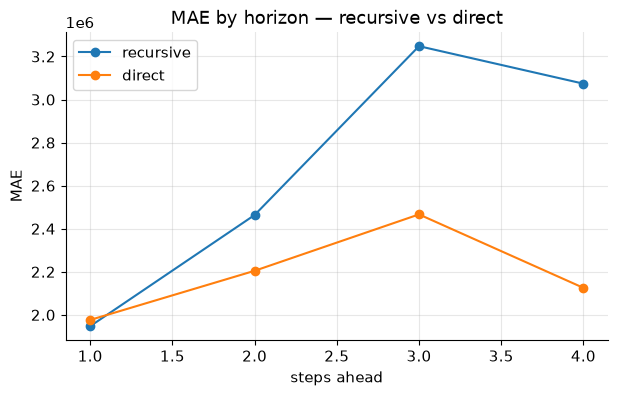

In [3]:
rec = bt.rolling_origin(y, ml.gbm_recursive_forecaster(target="growth"), initial=40, h=4)
dir_ = bt.rolling_origin(y, ml.gbm_direct_forecaster(target="growth"), initial=40, h=4)
tbl = pd.concat([bt.summarize_by_horizon(rec)["MAE"].rename("recursive"),
                 bt.summarize_by_horizon(dir_)["MAE"].rename("direct")], axis=1)
print(tbl.round(0))

fig, ax = plt.subplots(figsize=(7, 4))
tbl.plot(marker="o", ax=ax)
ax.set(title="MAE by horizon — recursive vs direct", xlabel="steps ahead", ylabel="MAE")
plt.show()

On this series **direct edges recursive** (and both beat the baselines) — the
recursive model's compounding hurts more than direct's data-thinning, at these short
horizons. The general guidance:

* **Recursive** — few data, short horizons, when the latest observation is highly
  informative.
* **Direct** — enough data to train $h$ models, longer horizons where compounding
  bites. (A hybrid, *DirRec*, exists too.)

---
**Next (03):** open the black box — which features matter, and how to tune a tree on
~80 rows without overfitting.